# 05 — 分季設定溫度推算與節電反事實計算

## 研究問題
1. 各教學館在不同學期（上學期、下學期、寒暑假）的冷氣設定溫度各是多少？  
2. 若全面調整至 26°C（政府標準），或延遲到 09:00 才開機，能省多少電？

## 方法論基礎

### 步驟一：用永續辦公室方法重算各館空調負載
依 `08_計算館舍不同日子用電值.py` 的分解公式，從各館的小時用電資料，  
分離出四個成分：

| 符號 | 說明 |
|---|---|
| A | 館舍基礎用電（不用人、不用空調的底電）|
| C+D | 設備待機用電（含暖季增量）|
| E+F | 人員設備使用用電（上班研究 + 上課）|
| **G+H** | **人員空調使用用電（上班空調 + 上課空調）← 這是反事實的基礎** |

### 步驟二：分季推算設定溫度（拐點法）
對每個學期（season），取上課日 × 上課時段（08–22時）的小時電力與氣溫，  
對「AC 用電 vs 室外溫度」進行**分段線性回歸（piecewise linear regression）**，  
轉折點即為推估的該季設定溫度 T_set。

> **理論依據：** 冷氣降溫電力 ∝ max(0, T_outdoor − T_set)。  
> 當室外溫度低於設定溫度時，壓縮機不啟動，用電為基礎負載。  
> 超過設定溫度後，用電線性上升，斜率反映建物熱負載特性與設備效率（COP）。  
> 兩段的交叉點即為 T_set 的最大似然估計。

### 步驟三：CDH 比例縮放法計算反事實節電量

```
CDH(T_set) = Σ max(0, T_outdoor − T_set)   ← 冷卻度時數
savings_fraction = 1 − CDH(26) / CDH(T_set)
annual_savings_kWh = (G+H) × savings_fraction × AC_operating_hours
```

**分季節電量** 以各季的 CDH 分別計算，加總得全年值。  
**延遲開機**（09:00 才開機）則直接比較 08:00–09:00 這段時間的 CDH 佔比。

---

In [1]:
import platform
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
from pathlib import Path
from scipy.optimize import minimize_scalar
from scipy import stats

# ── 中文字型 ──────────────────────────────────────────────────────────
def find_cjk_font():
    for repo_path in (Path('fonts').glob('*.tt[cf]') if Path('fonts').exists() else []):
        fm.fontManager.addfont(str(repo_path))
        return fm.FontProperties(fname=str(repo_path)).get_name()
    candidates = {
        'Darwin': ['/Library/Fonts/SourceHanSerif-SemiBold.ttc',
                   '/System/Library/Fonts/STHeiti Medium.ttc'],
        'Windows': [r'C:\Windows\Fonts\msjh.ttc'],
        'Linux': ['/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'],
    }.get(platform.system(), [])
    for p in candidates:
        if Path(p).exists():
            fm.fontManager.addfont(p)
            return fm.FontProperties(fname=p).get_name()
    return 'sans-serif'

font_name = find_cjk_font()
plt.rcParams['font.family']      = font_name
plt.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)

print('環境設定完成')

環境設定完成


## 一、載入資料

In [2]:
# ── 電力資料 ──────────────────────────────────────────────────────────
df_ac       = pd.read_parquet('cleaned_data/ac_普通.parquet')          # 普通高壓空調（ground truth）
df_putong1  = pd.read_parquet('cleaned_data/putong1_普通新設一.parquet')
df_putong2  = pd.read_parquet('cleaned_data/putong2_普通新設二.parquet')
df_elevator = pd.read_parquet('cleaned_data/elevator_普通電梯.parquet')
df_gongtong = pd.read_parquet('cleaned_data/gongtong_共同教室.parquet')
df_boya1    = pd.read_parquet('cleaned_data/boya1_博雅館一.parquet')
df_boya2    = pd.read_parquet('cleaned_data/boya2_博雅館二.parquet')
df_boya3    = pd.read_parquet('cleaned_data/boya3_博雅三.parquet')
df_boya4    = pd.read_parquet('cleaned_data/boya4_博雅四.parquet')     # 注意：原 notebook 有誤，請確認路徑
df_xinsheng = pd.read_parquet('cleaned_data/xinsheng_新生大樓.parquet')

# ── 氣象資料 ──────────────────────────────────────────────────────────
weather = pd.read_csv('cleaned_data/weather_data_2016_2025.csv',
                      parse_dates=['ObsTime'], index_col='ObsTime')
temp = weather['Temperature'].where(lambda x: x > -9)  # 清除缺值代碼 -99.x

# ── 永續辦公室空調分解基礎值 ──────────────────────────────────────────
df_basic = pd.read_excel('永續辦公室/館舍用電基礎值.xlsx')
print(df_basic.columns.tolist())
df_basic.head()

['Unnamed: 0', '館舍ID', '館舍名稱', '館舍面積', '館舍基礎用電', '設備待機用電(+暖季)', '人員設備使用用電', '人員空調使用用電', '館舍基礎用電密度', '設備待機用電密度(+暖季)', '人員設備使用用電密度', '人員空調使用用電密度']


,Unnamed: 0,館舍ID,館舍名稱,館舍面積,館舍基礎用電,設備待機用電(+暖季),人員設備使用用電,人員空調使用用電,館舍基礎用電密度,設備待機用電密度(+暖季),人員設備使用用電密度,人員空調使用用電密度
0,0,KT0026,人文系大樓(育成C棟),567.11,0,0,5,3,0.00,0.00,0.01,0.01
1,1,AT4039,教學二期機車停車場(立體機車停車場),6567.66,20,5,11,19,0.00,0.00,0.00,0.00
2,2,AT2016,漁業陳列館,483.82,0,0,0,0,0.00,0.00,0.00,0.00
3,3,AT2030-D,物理系液氮機室,111.51,0,0,0,1,0.00,0.00,0.00,0.01
4,4,AT2016-A,漁業生物實驗室,95.41,0,0,0,0,0.00,0.00,0.00,0.00


## 二、日型與學期分類

延用 `04_counterfactual.ipynb` 的日型定義，並增加學期（season）欄位。

| 學期代碼 | 期間 | 說明 |
|---|---|---|
| `spring` | 2–6月中（2/1–6/20 近似）| 下學期 |
| `fall`   | 9–12月（9/1–12/31）| 上學期 |
| `winter_break` | 1月、2月前（1/1–1/31）| 寒假 |
| `summer_break` | 6月下旬–8月（6/21–8/31）| 暑假 |

In [3]:
# ── 國定假日 & 過年假日（來自 04_counterfactual.ipynb）────────────────
national_holidays = set([
    "2016-01-01","2016-02-28","2016-02-29","2016-04-04","2016-04-05","2016-06-09","2016-09-15","2016-10-10",
    "2017-01-01","2017-01-02","2017-02-28","2017-04-04","2017-05-30","2017-10-04","2017-10-10",
    "2018-01-01","2018-02-28","2018-04-04","2018-04-05","2018-06-18","2018-09-24","2018-10-10",
    "2019-01-01","2019-02-28","2019-04-04","2019-04-05","2019-06-07","2019-09-13","2019-10-10",
    "2020-01-01","2020-02-28","2020-04-02","2020-04-03","2020-04-04","2020-04-05","2020-06-25","2020-10-01","2020-10-09","2020-10-10","2020-10-11",
    "2021-01-01","2021-02-28","2021-03-01","2021-04-02","2021-04-03","2021-04-04","2021-04-05","2021-06-14","2021-09-21","2021-10-10","2021-10-11",
    "2022-01-01","2022-02-28","2022-04-02","2022-04-03","2022-04-04","2022-04-05","2022-06-03","2022-09-10","2022-10-10",
    "2023-01-01","2023-01-02","2023-02-28","2023-04-01","2023-04-02","2023-04-03","2023-04-04","2023-04-05","2023-06-22","2023-09-29","2023-10-10",
    "2024-01-01","2024-02-28","2024-04-04","2024-04-05","2024-04-06","2024-04-07","2024-06-10","2024-09-17","2024-10-10",
    "2025-01-01","2025-02-28","2025-04-03","2025-04-04","2025-04-05","2025-04-06","2025-05-31","2025-10-06","2025-10-10"
])
cny_holidays = set([
    "2016-02-07","2016-02-08","2016-02-09","2016-02-10","2016-02-11","2016-02-12",
    "2017-01-27","2017-01-28","2017-01-29","2017-01-30","2017-01-31","2017-02-01",
    "2018-02-15","2018-02-16","2018-02-17","2018-02-18","2018-02-19","2018-02-20",
    "2019-02-04","2019-02-05","2019-02-06","2019-02-07","2019-02-08","2019-02-09",
    "2020-01-24","2020-01-25","2020-01-26","2020-01-27","2020-01-28","2020-01-29",
    "2021-02-11","2021-02-12","2021-02-13","2021-02-14","2021-02-15","2021-02-16",
    "2022-01-31","2022-02-01","2022-02-02","2022-02-03","2022-02-04","2022-02-05",
    "2023-01-21","2023-01-22","2023-01-23","2023-01-24","2023-01-25","2023-01-26",
    "2024-02-09","2024-02-10","2024-02-11","2024-02-12","2024-02-13","2024-02-14",
    "2025-01-28","2025-01-29","2025-01-30","2025-01-31","2025-02-01","2025-02-02"
])

def get_day_type(dt):
    """日型：0=上課日 1=過年 2=例假日 3=寒暑假"""
    date_str = dt.strftime('%Y-%m-%d')
    if date_str in cny_holidays:
        return 1
    elif dt.month in [1, 7, 8] or (dt.month == 2 and dt.day <= 14):  # 寒暑假（近似）
        return 3
    elif date_str in national_holidays or dt.weekday() >= 5:
        return 2
    else:
        return 0

def get_season(dt):
    """學期分類"""
    m, d = dt.month, dt.day
    if m == 1 or (m == 2 and d <= 14):
        return 'winter_break'   # 寒假（1月 + 2月前半）
    elif (m == 2 and d > 14) or m in [3, 4, 5] or (m == 6 and d <= 20):
        return 'spring'         # 下學期（2/15–6/20）
    elif (m == 6 and d > 20) or m in [7, 8]:
        return 'summer_break'   # 暑假（6/21–8/31）
    else:  # 9–12月
        return 'fall'           # 上學期

# ── 建立主 DataFrame ──────────────────────────────────────────────────
temp_df = temp.to_frame(name='T')
temp_df['day_type'] = temp_df.index.map(get_day_type)
temp_df['season']   = temp_df.index.map(get_season)
temp_df['hour']     = temp_df.index.hour
temp_df['month']    = temp_df.index.month
temp_df['year']     = temp_df.index.year

# 合併普通高壓空調電力（僅普通館有獨立 AC 電表）
temp_df = temp_df.join(df_ac[['kw']].rename(columns={'kw': 'ac_kw'}))

season_counts = temp_df.groupby('season').size()
print('各學期小時數（2016–2025）：')
print(season_counts)

各學期小時數（2016–2025）：
season
fall            29280
spring          30312
summer_break    17280
winter_break    10800
dtype: int64


## 三、分季推算設定溫度（拐點法）

**方法：** 對各學期的「上課日、上課時段（08–22時）、暖月（3–10月）」資料，  
以**分段線性回歸（two-segment piecewise linear）** 找到 RSS 最小的轉折點 T\*。  
T\* 即該季的推估設定溫度。

**為何分季有意義？**
- 下學期（春季）外氣溫較低，若設定溫度相同，拐點出現的溫度帶不同。
- 暑假期間只有少數研究室開放，可能有別於上課日的設定行為。
- 分季拐點比全年單一拐點更能捕捉行為異質性，也是後續分季節電計算的基礎。

In [4]:
def piecewise_rss(t_break, T, Y):
    """計算給定轉折點 t_break 的兩段線性回歸 RSS。"""
    left  = T <= t_break
    right = T >  t_break
    rss = 0.0
    for mask in [left, right]:
        if mask.sum() < 2:
            return np.inf
        slope, intercept, *_ = stats.linregress(T[mask], Y[mask])
        rss += ((Y[mask] - (slope * T[mask] + intercept)) ** 2).sum()
    return rss

def estimate_t_set(df_season, ac_col='ac_kw', temp_col='T',
                   t_min=20.0, t_max=30.0):
    """
    從分季資料估算設定溫度。
    使用 scipy.optimize.minimize_scalar 尋找最佳轉折點。
    回傳 (t_set, r2_left, r2_right)
    """
    df = df_season[[temp_col, ac_col]].dropna()
    if len(df) < 20:
        return np.nan, np.nan, np.nan
    T = df[temp_col].values
    Y = df[ac_col].values

    result = minimize_scalar(
        piecewise_rss, bounds=(t_min, t_max), method='bounded',
        args=(T, Y)
    )
    t_set = result.x

    # 計算各段 R²
    def seg_r2(mask):
        if mask.sum() < 2:
            return np.nan
        s, i, r, *_ = stats.linregress(T[mask], Y[mask])
        return r ** 2

    r2_left  = seg_r2(T <= t_set)
    r2_right = seg_r2(T >  t_set)
    return t_set, r2_left, r2_right


# ── 對普通館（有獨立 AC 電表）分季估算 ───────────────────────────────
# 篩選：上課日 × 上課時段 × 暖月（3–10月，AC 可能啟動）
ac_base = temp_df[
    (temp_df['day_type'] == 0) &
    (temp_df['hour'].between(8, 22)) &
    (temp_df['month'].between(3, 10))
].copy()

seasons_of_interest = ['spring', 'fall', 'summer_break']
season_labels = {'spring': '下學期（2–6月）', 'fall': '上學期（9–12月）',
                 'summer_break': '暑假（7–8月）'}

t_set_results = {}
for season in seasons_of_interest:
    sub = ac_base[ac_base['season'] == season]
    t_set, r2l, r2r = estimate_t_set(sub)
    t_set_results[season] = {'T_set': t_set, 'R²_低溫段': r2l, 'R²_高溫段': r2r, 'n': len(sub)}
    print(f"{season_labels[season]:20s}  T_set={t_set:.1f}°C  "
          f"R²(左)={r2l:.3f}  R²(右)={r2r:.3f}  n={len(sub):,}")

df_tset = pd.DataFrame(t_set_results).T
df_tset

下學期（2–6月）             T_set=24.0°C  R²(左)=0.059  R²(右)=0.132  n=11,580
上學期（9–12月）            T_set=26.1°C  R²(左)=0.182  R²(右)=0.010  n=6,240
暑假（7–8月）              T_set=29.6°C  R²(左)=0.032  R²(右)=0.133  n=1,050


,T_set,R²_低溫段,R²_高溫段,n
spring,24.05,0.06,0.13,11580.00
fall,26.13,0.18,0.01,6240.00
summer_break,29.62,0.03,0.13,1050.00


### 視覺化：各季拐點

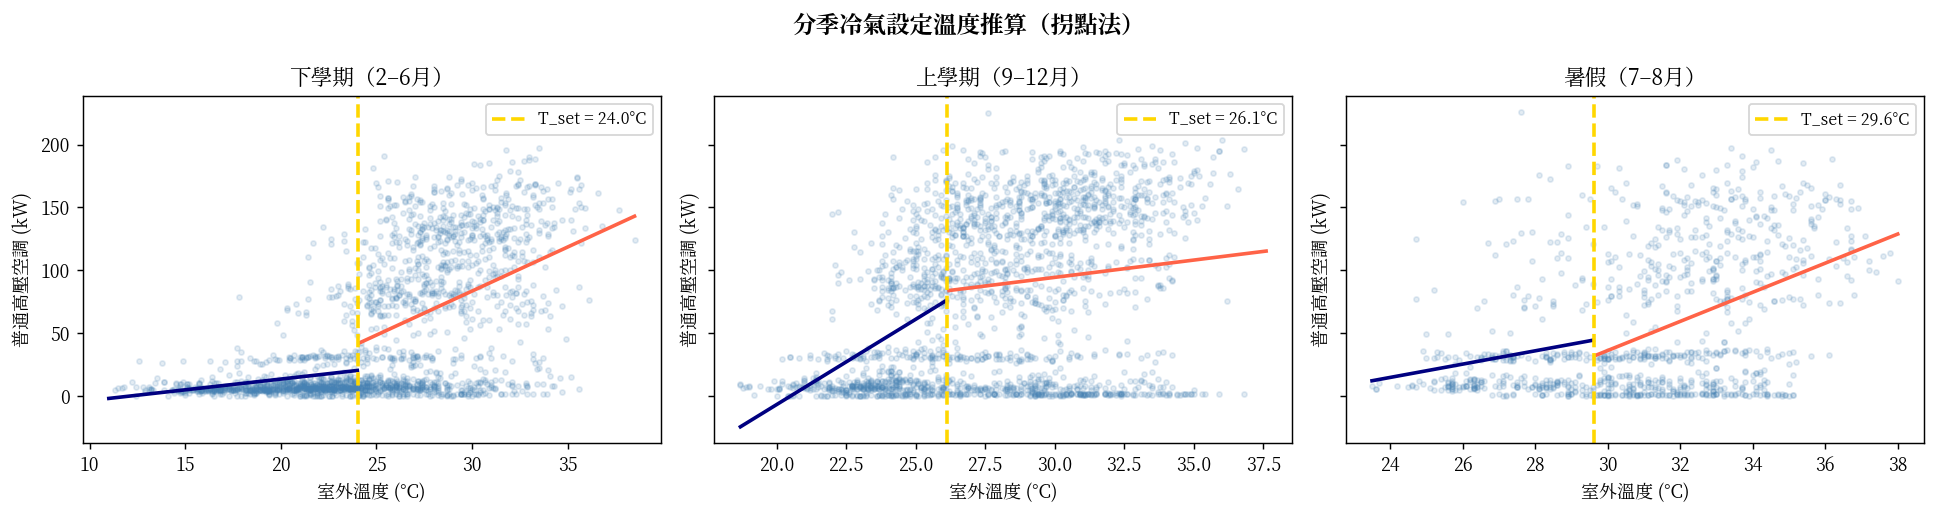

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=130, sharey=True)

for ax, season in zip(axes, seasons_of_interest):
    sub = ac_base[ac_base['season'] == season][['T', 'ac_kw']].dropna()
    t_set = t_set_results[season]['T_set']

    # 散點（隨機取樣，避免過密）
    samp = sub.sample(min(2000, len(sub)), random_state=42)
    ax.scatter(samp['T'], samp['ac_kw'], alpha=0.15, s=8, color='steelblue')

    # 兩段回歸線
    T = sub['T'].values; Y = sub['ac_kw'].values
    for mask, color in [(T <= t_set, 'navy'), (T > t_set, 'tomato')]:
        if mask.sum() >= 2:
            s, i, *_ = stats.linregress(T[mask], Y[mask])
            xs = np.linspace(T[mask].min(), T[mask].max(), 100)
            ax.plot(xs, s * xs + i, color=color, lw=2)

    ax.axvline(t_set, color='gold', lw=2, linestyle='--',
               label=f'T_set = {t_set:.1f}°C')
    ax.set_title(season_labels[season])
    ax.set_xlabel('室外溫度 (°C)')
    ax.set_ylabel('普通高壓空調 (kW)')
    ax.legend(fontsize=9)

plt.suptitle('分季冷氣設定溫度推算（拐點法）', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cleaned_data/seasonal_t_set_piecewise.png', dpi=150, bbox_inches='tight')
plt.show()

## 四、分季 CDH 節電比例

### 核心公式
```
CDH(T_set, season) = Σ_{上課日上課時段} max(0, T_outdoor − T_set)
savings_fraction(season) = 1 − CDH(26, season) / CDH(T_set, season)
```

各季節電比例不同：  
- 下學期（春季）氣溫較低，超過 26°C 的時數少，節電比例可能**低**（因為現有超過設定溫度的時數也不多）。  
- 上學期（秋季）9–10月氣溫仍高，設定溫度若比 26°C 低，節電比例較大。

### 延遲開機（09:00 才開機）節電
AC 少運行 08:00–08:59 這一小時，節電量直接估為：  
```
early_savings = (G+H) × Σ_{08:00–09:00} max(0, T − T_set) / CDH(T_set)
```

In [6]:
T_STD = 26.0  # 政府建議標準

# ── 各季 CDH 計算 ─────────────────────────────────────────────────────
season_cdh = {}

for season in seasons_of_interest:
    t_set = t_set_results[season]['T_set']
    if np.isnan(t_set):
        continue

    # 上課日 × 上課時段（08–22h）× 暖季（3–10月）
    mask_full = (
        (temp_df['day_type'] == 0) &
        (temp_df['hour'].between(8, 22)) &
        (temp_df['month'].between(3, 10)) &
        (temp_df['season'] == season) &
        (temp_df['T'].notna())
    )
    # 延遲開機：只有 08:00 這小時
    mask_early = mask_full & (temp_df['hour'] == 8)

    sub      = temp_df[mask_full]
    sub_early = temp_df[mask_early]

    cdh_tset  = (sub['T'] - t_set).clip(lower=0).sum()
    cdh_26    = (sub['T'] - T_STD).clip(lower=0).sum()
    cdh_early = (sub_early['T'] - t_set).clip(lower=0).sum()  # 08:00 一小時的 CDH

    sf_26    = 1 - cdh_26 / cdh_tset  if cdh_tset > 0 else 0
    sf_early = cdh_early / cdh_tset   if cdh_tset > 0 else 0  # 延遲開機節省比例

    season_cdh[season] = {
        'T_set': t_set,
        'CDH_Tset': cdh_tset,
        'CDH_26': cdh_26,
        'CDH_08h': cdh_early,
        'savings_fraction_26C': sf_26,
        'savings_fraction_delay': sf_early,
        'ac_hours_total': len(sub),
        'ac_hours_per_year': len(sub) / (temp_df['year'].nunique()),
    }

df_cdh = pd.DataFrame(season_cdh).T
df_cdh.index = [season_labels[s] for s in df_cdh.index]
print('=== 各季 CDH 與節電比例 ===')
df_cdh[['T_set','CDH_Tset','CDH_26','savings_fraction_26C','savings_fraction_delay','ac_hours_per_year']]

=== 各季 CDH 與節電比例 ===


,T_set,CDH_Tset,CDH_26,savings_fraction_26C,savings_fraction_delay,ac_hours_per_year
下學期（2–6月）,24.05,29808.85,18359.80,0.38,0.04,1157.90
上學期（9–12月）,26.13,16052.80,16599.10,-0.03,0.04,624.00
暑假（7–8月）,29.62,2191.27,5318.80,-1.43,0.02,105.00


## 五、套用永續辦公室分解值 → 各館分季節電量

### 目標館舍（有永續辦公室分解值）
從 `df_basic` 取「人員空調使用用電」（G+H），乘以各季的節電比例與年化AC運行小時，  
得到該館、該季、該情境的年化節電量。

> **注意：** 永續辦公室的分解值是基於「全館」行為，包含教室、辦公室等。  
> 若設定溫度只是教室空調的設定，整體節電效果需按面積或使用比例折算。  
> 此處以全館值為保守上界估計。

In [7]:
# 目標館舍（依永續辦公室 df_basic 的館舍名稱調整）
# 請確認館舍名稱與 df_basic['館舍名稱'] 一致
TARGET_BUILDINGS = {
    '普通教學館': None,  # 從 df_basic 查
    '博雅教學館': None,
    '新生教學館': None,
    '共同教學館': None,
}

# 查找各館在 df_basic 的 人員空調使用用電
def get_ac_kw(name_keywords, df):
    """模糊搜尋館舍名稱，回傳 人員空調使用用電 (kW)"""
    mask = df['館舍名稱'].str.contains('|'.join(name_keywords), na=False)
    matched = df[mask]
    if matched.empty:
        print(f'  ⚠ 找不到：{name_keywords}')
        return np.nan
    return matched['人員空調使用用電'].sum()  # 若有多筆則加總

TARGET_KEYWORDS = {
    '普通教學館': ['普通'],
    '博雅教學館': ['博雅'],
    '新生教學館': ['新生'],
    '共同教學館': ['共同'],
}

for bldg, kw_list in TARGET_KEYWORDS.items():
    ac_kw = get_ac_kw(kw_list, df_basic)
    TARGET_BUILDINGS[bldg] = ac_kw
    print(f'{bldg}: 人員空調使用用電 = {ac_kw:.0f} kW')

TARIFF = 3.5    # 元/kWh（高壓用電，請依最新台電費率更新）
EF     = 0.494  # kg CO₂e/kWh（2023 能源局排放係數）

print('\n=== 分季節電量計算 ===')
all_rows = []
for bldg, ac_kw in TARGET_BUILDINGS.items():
    if np.isnan(ac_kw):
        continue
    for season, cdh_info in season_cdh.items():
        hrs_yr = cdh_info['ac_hours_per_year']  # 年平均AC有效運行小時（該季）
        # 情境1：26°C
        sf_26  = cdh_info['savings_fraction_26C']
        kwh_26 = ac_kw * sf_26 * hrs_yr
        # 情境2：延遲開機至 09:00
        sf_dl  = cdh_info['savings_fraction_delay']
        kwh_dl = ac_kw * sf_dl * hrs_yr

        all_rows.append({
            '館舍': bldg,
            '學期': season_labels[season],
            '推估設定溫度(°C)': cdh_info['T_set'],
            '人員空調用電(kW)': ac_kw,
            'AC年均時數': hrs_yr,
            '節電比例_26C': sf_26,
            '節電量_26C(kWh/yr)': kwh_26,
            '節費_26C(元/yr)': kwh_26 * TARIFF,
            '減碳_26C(kgCO2/yr)': kwh_26 * EF,
            '節電比例_延遲開機': sf_dl,
            '節電量_延遲開機(kWh/yr)': kwh_dl,
            '節費_延遲開機(元/yr)': kwh_dl * TARIFF,
        })

df_out = pd.DataFrame(all_rows)
print(df_out[['館舍','學期','推估設定溫度(°C)','節電比例_26C','節電量_26C(kWh/yr)','節電比例_延遲開機','節電量_延遲開機(kWh/yr)']].to_string(index=False))

普通教學館: 人員空調使用用電 = 119 kW
博雅教學館: 人員空調使用用電 = 94 kW
新生教學館: 人員空調使用用電 = 113 kW
共同教學館: 人員空調使用用電 = 118 kW

=== 分季節電量計算 ===
   館舍         學期  推估設定溫度(°C)  節電比例_26C  節電量_26C(kWh/yr)  節電比例_延遲開機  節電量_延遲開機(kWh/yr)
普通教學館  下學期（2–6月）       24.05      0.38         52922.74       0.04           5339.02
普通教學館 上學期（9–12月）       26.13     -0.03         -2527.05       0.04           2845.18
普通教學館   暑假（7–8月）       29.62     -1.43        -17833.66       0.02            198.53
博雅教學館  下學期（2–6月）       24.05      0.38         41804.52       0.04           4217.38
博雅教學館 上學期（9–12月）       26.13     -0.03         -1996.16       0.04           2247.45
博雅教學館   暑假（7–8月）       29.62     -1.43        -14087.09       0.02            156.82
新生教學館  下學期（2–6月）       24.05      0.38         50254.37       0.04           5069.83
新生教學館 上學期（9–12月）       26.13     -0.03         -2399.64       0.04           2701.72
新生教學館   暑假（7–8月）       29.62     -1.43        -16934.48       0.02            188.52
共同教學館  下學期（2–6月）       24.05      

## 六、年度合計與視覺化

In [8]:
# 年度合計（各館加總所有學期）
df_annual = df_out.groupby('館舍').agg(
    人員空調用電_kW=('人員空調用電(kW)', 'first'),
    年節電_26C_kWh=('節電量_26C(kWh/yr)', 'sum'),
    年節費_26C_元=('節費_26C(元/yr)', 'sum'),
    年減碳_26C_kg=('減碳_26C(kgCO2/yr)', 'sum'),
    年節電_延遲_kWh=('節電量_延遲開機(kWh/yr)', 'sum'),
    年節費_延遲_元=('節費_延遲開機(元/yr)', 'sum'),
).reset_index()
df_annual['年節電_兩措施合計_kWh'] = df_annual['年節電_26C_kWh'] + df_annual['年節電_延遲_kWh']

print('=== 四大教學館年度節電效益 ===')
print(df_annual.to_string(index=False))
print()
print(f"四館合計 節電_26C: {df_annual['年節電_26C_kWh'].sum():,.0f} kWh/yr  "
      f"電費: {df_annual['年節費_26C_元'].sum()/1e4:.1f} 萬元/yr  "
      f"減碳: {df_annual['年減碳_26C_kg'].sum()/1e3:.1f} 公噸CO₂/yr")
print(f"四館合計 節電_延遲: {df_annual['年節電_延遲_kWh'].sum():,.0f} kWh/yr")

=== 四大教學館年度節電效益 ===
   館舍  人員空調用電_kW  年節電_26C_kWh  年節費_26C_元  年減碳_26C_kg  年節電_延遲_kWh  年節費_延遲_元  年節電_兩措施合計_kWh
共同教學館        118     32288.40  113009.39    15950.47     8312.29  29093.01       40600.69
博雅教學館         94     25721.26   90024.43    12706.30     6621.65  23175.79       32342.92
新生教學館        113     30920.24  108220.85    15274.60     7960.07  27860.26       38880.32
普通教學館        119     32562.03  113967.09    16085.64     8382.73  29339.56       40944.76

四館合計 節電_26C: 121,492 kWh/yr  電費: 42.5 萬元/yr  減碳: 60.0 公噸CO₂/yr
四館合計 節電_延遲: 31,277 kWh/yr


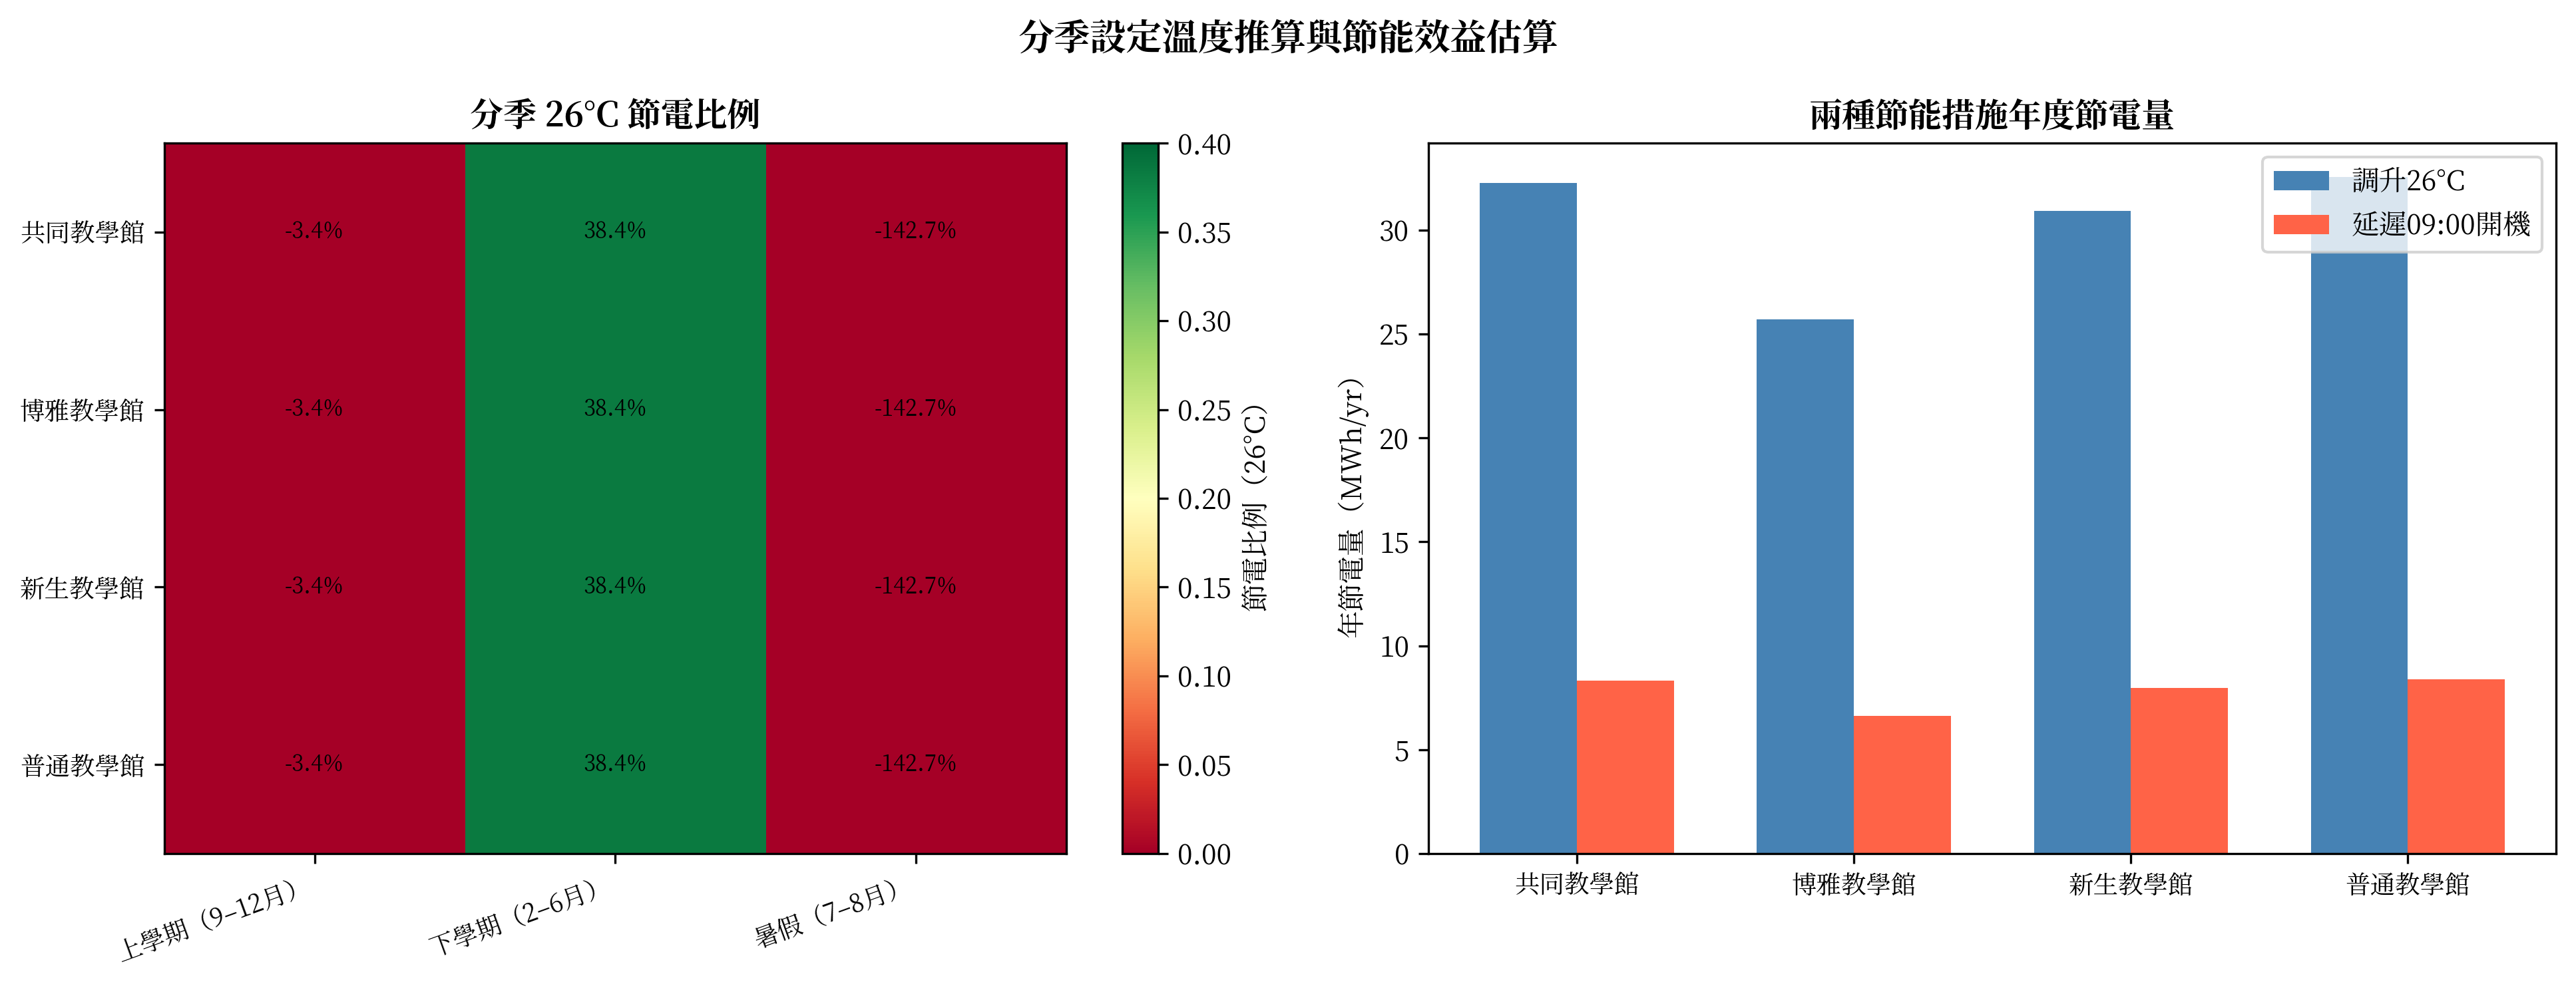

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=300)

# 左：分季節電比例（熱圖）
ax = axes[0]
pivot_sf = df_out.pivot_table(
    index='館舍', columns='學期', values='節電比例_26C', aggfunc='mean'
)
im = ax.imshow(pivot_sf.values, cmap='RdYlGn', vmin=0, vmax=0.4, aspect='auto')
ax.set_xticks(range(len(pivot_sf.columns)))
ax.set_xticklabels(pivot_sf.columns, rotation=20, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot_sf.index)))
ax.set_yticklabels(pivot_sf.index, fontsize=9)
for i in range(len(pivot_sf.index)):
    for j in range(len(pivot_sf.columns)):
        val = pivot_sf.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.1%}', ha='center', va='center', fontsize=8,
                    color='black')
plt.colorbar(im, ax=ax, label='節電比例（26°C）')
ax.set_title('分季 26°C 節電比例', fontweight='bold')

# 右：年度節電量（兩措施）
ax2 = axes[1]
x = np.arange(len(df_annual))
w = 0.35
ax2.bar(x - w/2, df_annual['年節電_26C_kWh']/1000, w, label='調升26°C', color='steelblue')
ax2.bar(x + w/2, df_annual['年節電_延遲_kWh']/1000, w, label='延遲09:00開機', color='tomato')
ax2.set_xticks(x)
ax2.set_xticklabels(df_annual['館舍'], fontsize=9)
ax2.set_ylabel('年節電量（MWh/yr）')
ax2.set_title('兩種節能措施年度節電量', fontweight='bold')
ax2.legend()

plt.suptitle('分季設定溫度推算與節能效益估算', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cleaned_data/seasonal_savings_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 七、全校 145 棟推估

以各季的加權平均節電比例套用至全校 `df_basic['人員空調使用用電']`。  
加權方式：以各季 CDH(T_set) 為權重，反映各季空調實際負荷佔比。

In [10]:
# 全校空調尖峰負載
campus_ac_kw = df_basic['人員空調使用用電'].sum()
print(f'全校 145 棟空調負載合計：{campus_ac_kw:,.0f} kW')

# 加權平均節電比例（以各季 CDH 為權重）
total_cdh   = sum(v['CDH_Tset'] for v in season_cdh.values())
w_sf_26     = sum(v['savings_fraction_26C']    * v['CDH_Tset'] for v in season_cdh.values()) / total_cdh
w_sf_delay  = sum(v['savings_fraction_delay']  * v['CDH_Tset'] for v in season_cdh.values()) / total_cdh
total_hrs   = sum(v['ac_hours_per_year'] for v in season_cdh.values())

campus_kwh_26    = campus_ac_kw * w_sf_26   * total_hrs
campus_kwh_delay = campus_ac_kw * w_sf_delay * total_hrs

print(f'\n加權平均節電比例_26C：   {w_sf_26:.1%}')
print(f'加權平均節電比例_延遲：  {w_sf_delay:.1%}')
print(f'\n=== 全校 145 棟年度節電潛力 ===')
print(f'調升 26°C：     {campus_kwh_26/1e6:.2f} GWh/yr  |  {campus_kwh_26*TARIFF/1e6:.1f} 百萬元  |  {campus_kwh_26*EF/1e6:.0f} 公噸CO₂')
print(f'延遲09時開機：  {campus_kwh_delay/1e6:.2f} GWh/yr  |  {campus_kwh_delay*TARIFF/1e6:.1f} 百萬元')
print(f'兩措施合計：    {(campus_kwh_26+campus_kwh_delay)/1e6:.2f} GWh/yr')

全校 145 棟空調負載合計：8,132 kW

加權平均節電比例_26C：   16.2%
加權平均節電比例_延遲：  3.8%

=== 全校 145 棟年度節電潛力 ===
調升 26°C：     2.48 GWh/yr  |  8.7 百萬元  |  1 公噸CO₂
延遲09時開機：  0.58 GWh/yr  |  2.0 百萬元
兩措施合計：    3.06 GWh/yr


## 八、敏感度分析

拐點推估有 ±1°C 不確定性；以 T_set ± 1°C 測試結果穩健性。

In [11]:
sensitivity_rows = []
for delta in [-1.0, 0.0, +1.0]:
    total_cdh_d = 0; w26 = 0; wd = 0; hrs = 0
    for season, info in season_cdh.items():
        t_adj = info['T_set'] + delta
        mask = (
            (temp_df['day_type'] == 0) &
            (temp_df['hour'].between(8, 22)) &
            (temp_df['month'].between(3, 10)) &
            (temp_df['season'] == season) &
            (temp_df['T'].notna())
        )
        sub = temp_df[mask]
        cdh_t = (sub['T'] - t_adj).clip(lower=0).sum()
        cdh_26= (sub['T'] - T_STD).clip(lower=0).sum()
        cdh_e = (sub[sub['hour']==8]['T'] - t_adj).clip(lower=0).sum()
        sf26 = 1 - cdh_26/cdh_t if cdh_t > 0 else 0
        sfd  = cdh_e/cdh_t      if cdh_t > 0 else 0
        n    = len(sub) / temp_df['year'].nunique()
        total_cdh_d += cdh_t
        w26 += sf26 * cdh_t; wd += sfd * cdh_t; hrs += n
    w26 /= total_cdh_d; wd /= total_cdh_d
    kwh26 = campus_ac_kw * w26 * hrs
    kwh_d = campus_ac_kw * wd  * hrs
    sensitivity_rows.append({
        '設定溫度偏移': f'{delta:+.0f}°C',
        '加權節電比例_26C': f'{w26:.1%}',
        '全校年節電_26C(萬kWh)': f'{kwh26/1e4:.0f}',
        '全校年節費_26C(百萬元)': f'{kwh26*TARIFF/1e6:.1f}',
        '全校年節電_延遲(萬kWh)': f'{kwh_d/1e4:.0f}',
    })

df_sens = pd.DataFrame(sensitivity_rows)
print('=== 敏感度分析（T_set ± 1°C）===')
print(df_sens.to_string(index=False))

=== 敏感度分析（T_set ± 1°C）===
設定溫度偏移 加權節電比例_26C 全校年節電_26C(萬kWh) 全校年節費_26C(百萬元) 全校年節電_延遲(萬kWh)
  -1°C      33.2%             510           17.9             64
  +0°C      16.2%             248            8.7             58
  +1°C      -8.1%            -125           -4.4             50


## 九、輸出結果

In [12]:
with pd.ExcelWriter('cleaned_data/seasonal_ac_savings.xlsx') as writer:
    df_tset.to_excel(writer, sheet_name='分季設定溫度')
    df_cdh.to_excel(writer, sheet_name='分季CDH節電比例')
    df_out.to_excel(writer, sheet_name='四館分季節電量', index=False)
    df_annual.to_excel(writer, sheet_name='四館年度合計', index=False)
    df_sens.to_excel(writer, sheet_name='敏感度分析', index=False)
print('結果已輸出至 cleaned_data/seasonal_ac_savings.xlsx')

結果已輸出至 cleaned_data/seasonal_ac_savings.xlsx
